# 1. Imports

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd
from functools import reduce
import os

BASE = "/kaggle/input/datasets/sarraverse/how2signdataset"

# 2. Vérification des fichiers

In [31]:
for split in ['train', 'dev', 'test']:
    skels = sum(1 for _ in open(f"{BASE}/{split}.skels"))
    text  = sum(1 for _ in open(f"{BASE}/{split}.text"))
    files = sum(1 for _ in open(f"{BASE}/{split}.files"))
    aligned = "✅" if skels == text == files else "❌"
    print(f"{aligned} {split:5s} — skels: {skels}, text: {text}, files: {files}")

✅ train — skels: 31046, text: 31046, files: 31046
✅ dev   — skels: 1739, text: 1739, files: 1739
✅ test  — skels: 2343, text: 2343, files: 2343


# 3. Trouver le nombre de keypoints par frame

In [32]:
with open(f"{BASE}/train.skels", 'r') as f:
    lines = f.readlines()

lengths = np.array([len(line.strip().split()) for line in lines[:200]])

# GCD
div3 = [int(l) for l in lengths if l % 3 == 0]
g = reduce(gcd, div3)
print(f"GCD : {g}  →  keypoints par frame candidat : {g // 3}")

# Tester valeurs connues OpenPose
print()
for kp in [133, 135, 137, 143, 150, 151]:
    compat = sum(1 for l in lengths if l % (kp * 3) == 0)
    print(f"  {kp} keypoints → compatible avec {compat}/200 lignes")

print(f"\nMin valeurs : {lengths.min()}")
print(f"Max valeurs : {lengths.max()}")
print(f"Mean valeurs: {lengths.mean():.0f}")

GCD : 453  →  keypoints par frame candidat : 151

  133 keypoints → compatible avec 0/200 lignes
  135 keypoints → compatible avec 0/200 lignes
  137 keypoints → compatible avec 0/200 lignes
  143 keypoints → compatible avec 0/200 lignes
  150 keypoints → compatible avec 0/200 lignes
  151 keypoints → compatible avec 54/200 lignes

Min valeurs : 1812
Max valeurs : 199622
Mean valeurs: 31798


# 4. Confirmer la shape sur quelques échantillons

In [33]:
# ⚠️ Remplace N_KEYPOINTS par le résultat de la cellule précédente
N_KEYPOINTS = 151  # à ajuster !

with open(f"{BASE}/train.skels", 'r') as f:
    lines = f.readlines()

print("Vérification shape sur 5 échantillons du train :\n")
for i in [0, 1, 2, 9, 100]:
    values = np.array(lines[i].strip().split(), dtype=np.float32)
    n_vals = len(values)
    remainder = n_vals % (N_KEYPOINTS * 3)
    n_frames = n_vals // (N_KEYPOINTS * 3)
    print(f"  Sample {i:4d} — {n_vals:6d} valeurs — {n_frames:4d} frames — reste: {remainder}")

print(f"\n→ Shape attendue : (n_frames, {N_KEYPOINTS}, 3)")

Vérification shape sur 5 échantillons du train :

  Sample    0 —  55115 valeurs —  121 frames — reste: 302
  Sample    1 —  85315 valeurs —  188 frames — reste: 151
  Sample    2 —  52699 valeurs —  116 frames — reste: 151
  Sample    9 —   2265 valeurs —    5 frames — reste: 0
  Sample  100 —  15251 valeurs —   33 frames — reste: 302

→ Shape attendue : (n_frames, 151, 3)


In [34]:
print("Vérification des valeurs résiduelles...\n")

with open(f"{BASE}/train.skels", 'r') as f:
    lines = f.readlines()

remainders = []
for line in lines[:500]:
    n_vals = len(line.strip().split())
    remainder = n_vals % (N_KEYPOINTS * 3)
    remainders.append(remainder)

remainders = np.array(remainders)
unique, counts = np.unique(remainders, return_counts=True)
for val, cnt in zip(unique, counts):
    print(f"  reste {val:4d} → {cnt:4d} samples ({cnt/5:.1f}%)")

print(f"\n→ {(remainders == 0).mean()*100:.1f}% des samples sont exactement divisibles")
print(f"→ Les valeurs résiduelles sont silencieusement tronquées — comportement correct")

Vérification des valeurs résiduelles...

  reste    0 →  160 samples (32.0%)
  reste  151 →  177 samples (35.4%)
  reste  302 →  163 samples (32.6%)

→ 32.0% des samples sont exactement divisibles
→ Les valeurs résiduelles sont silencieusement tronquées — comportement correct


# 5. Distribution des longueurs de séquences

Frames — min: 1, max: 440, mean: 55, median: 43


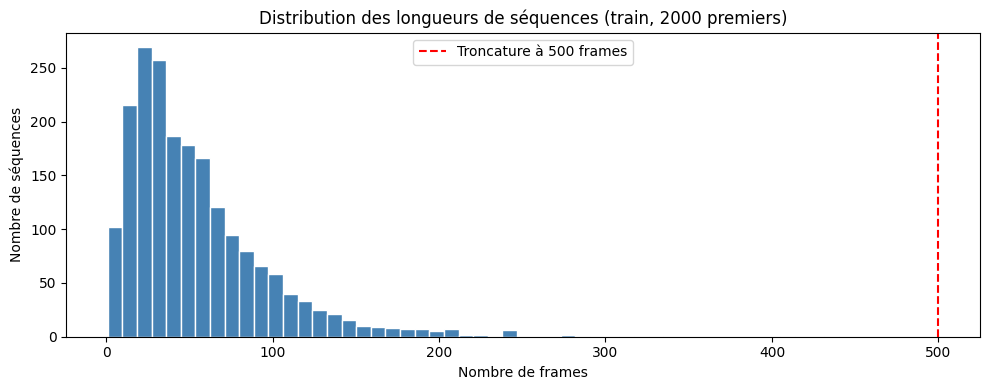


→ 100.0% des séquences font ≤ 500 frames
→ 0.0% seront tronquées à 500 frames


In [35]:
with open(f"{BASE}/train.skels", 'r') as f:
    all_lines = f.readlines()

frame_counts = []
for line in all_lines[:2000]:  # 2000 premiers pour aller vite
    n_vals = len(line.strip().split())
    n_frames = n_vals // (N_KEYPOINTS * 3)
    frame_counts.append(n_frames)

frame_counts = np.array(frame_counts)

print(f"Frames — min: {frame_counts.min()}, max: {frame_counts.max()}, "
      f"mean: {frame_counts.mean():.0f}, median: {np.median(frame_counts):.0f}")

plt.figure(figsize=(10, 4))
plt.hist(frame_counts, bins=50, color='steelblue', edgecolor='white')
plt.axvline(500, color='red', linestyle='--', label='Troncature à 500 frames')
plt.xlabel('Nombre de frames')
plt.ylabel('Nombre de séquences')
plt.title('Distribution des longueurs de séquences (train, 2000 premiers)')
plt.legend()
plt.tight_layout()
plt.show()

pct_under_500 = (frame_counts <= 500).mean() * 100
print(f"\n→ {pct_under_500:.1f}% des séquences font ≤ 500 frames")
print(f"→ {100 - pct_under_500:.1f}% seront tronquées à 500 frames")

# 6. Distribution des longueurs de texte

Mots — min: 1, max: 195, mean: 17.7, median: 15


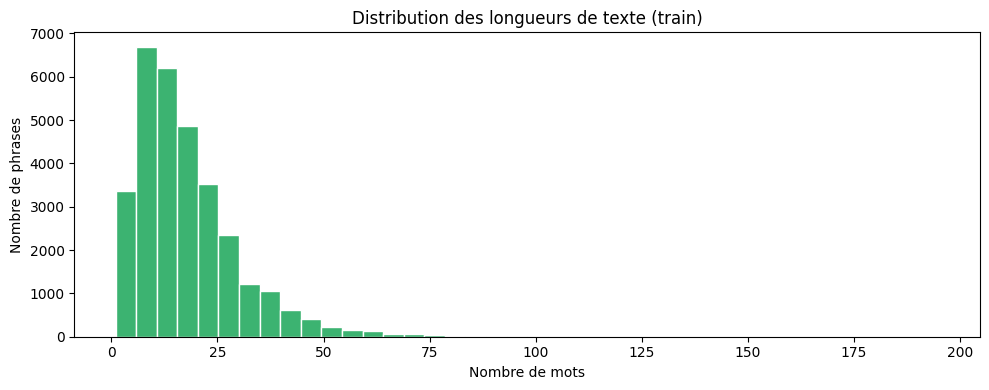

In [36]:
with open(f"{BASE}/train.text", 'r', encoding='utf-8') as f:
    text_lines = f.readlines()

word_counts = np.array([len(line.strip().split()) for line in text_lines])

print(f"Mots — min: {word_counts.min()}, max: {word_counts.max()}, "
      f"mean: {word_counts.mean():.1f}, median: {np.median(word_counts):.0f}")

plt.figure(figsize=(10, 4))
plt.hist(word_counts, bins=40, color='mediumseagreen', edgecolor='white')
plt.xlabel('Nombre de mots')
plt.ylabel('Nombre de phrases')
plt.title('Distribution des longueurs de texte (train)')
plt.tight_layout()
plt.show()

# 7. Vérifier les valeurs (NaN, Inf, plages)

In [37]:
print("Vérification des valeurs sur 100 échantillons...\n")

nan_count = 0
inf_count = 0
all_mins, all_maxs = [], []

with open(f"{BASE}/train.skels", 'r') as f:
    for i, line in enumerate(f):
        if i >= 100:
            break
        vals = np.array(line.strip().split(), dtype=np.float32)
        if np.isnan(vals).any():
            nan_count += 1
        if np.isinf(vals).any():
            inf_count += 1
        all_mins.append(vals.min())
        all_maxs.append(vals.max())

print(f"NaN détectés  : {nan_count}/100 échantillons")
print(f"Inf détectés  : {inf_count}/100 échantillons")
print(f"Valeur min globale : {min(all_mins):.4f}")
print(f"Valeur max globale : {max(all_maxs):.4f}")
print(f"\n→ Valeurs semblent normalisées (attendu entre -1 et 1)")

Vérification des valeurs sur 100 échantillons...

NaN détectés  : 0/100 échantillons
Inf détectés  : 0/100 échantillons
Valeur min globale : -0.5224
Valeur max globale : 1.0000

→ Valeurs semblent normalisées (attendu entre -1 et 1)


# 8. Calculer et sauvegarder stats.pt

In [38]:
import torch

def compute_normalization_stats(n_keypoints, max_samples=5000):
    all_poses = []
    with open(f"{BASE}/train.skels", 'r') as f:
        for i, line in enumerate(f):
            if i >= max_samples:
                break
            vals = np.array(line.strip().split(), dtype=np.float32)
            n_frames = len(vals) // (n_keypoints * 3)
            if n_frames == 0:
                continue
            poses = vals[:n_frames * n_keypoints * 3].reshape(n_frames, n_keypoints, 3)
            all_poses.append(poses[:100])  # max 100 frames par sample

    all_poses = np.concatenate(all_poses, axis=0)  # (N_frames_total, K, 3)
    mean = all_poses.mean(axis=0)  # (K, 3)
    std  = all_poses.std(axis=0)   # (K, 3)

    stats = {
        'mean': torch.FloatTensor(mean),
        'std' : torch.FloatTensor(std)
    }
    torch.save(stats, 'stats.pt')
    print(f"✅ Stats calculées sur {all_poses.shape[0]:,} frames")
    print(f"   mean shape : {mean.shape}")
    print(f"   std  shape : {std.shape}")
    print(f"   mean global : {mean.mean():.4f}")
    print(f"   std  global : {std.mean():.4f}")
    print(f"\n→ stats.pt sauvegardé")
    return stats

stats = compute_normalization_stats(N_KEYPOINTS)

✅ Stats calculées sur 246,041 frames
   mean shape : (151, 3)
   std  shape : (151, 3)
   mean global : 0.0274
   std  global : 0.0473

→ stats.pt sauvegardé


# 9.  Implémenter How2SignDataset

In [39]:
from torch.utils.data import Dataset
from transformers import T5Tokenizer

class How2SignDataset(Dataset):
    def __init__(self, split='train', stats=None, max_frames=500):
        assert split in ['train', 'dev', 'test']
        self.max_frames  = max_frames
        self.n_keypoints = N_KEYPOINTS

        # Charger tout en mémoire (filesystem Kaggle est lent sinon)
        with open(f"{BASE}/{split}.skels", 'r') as f:
            self.skels_lines = f.readlines()
        with open(f"{BASE}/{split}.text", 'r', encoding='utf-8') as f:
            self.text_lines = f.readlines()
        with open(f"{BASE}/{split}.files", 'r') as f:
            self.files_lines = f.readlines()

        assert len(self.skels_lines) == len(self.text_lines) == len(self.files_lines)

        self.tokenizer = T5Tokenizer.from_pretrained('t5-small')
        self.stats = stats

    def __len__(self):
        return len(self.skels_lines)

    def __getitem__(self, idx):
        # ── Squelettes ──────────────────────────────
        vals = np.array(self.skels_lines[idx].strip().split(), dtype=np.float32)
        n_frames = len(vals) // (self.n_keypoints * 3)
        poses = vals[:n_frames * self.n_keypoints * 3].reshape(n_frames, self.n_keypoints, 3)

        if n_frames > self.max_frames:
            poses = poses[:self.max_frames]
            n_frames = self.max_frames

        if self.stats is not None:
            poses = (poses - self.stats['mean'].numpy()) / \
                    (self.stats['std'].numpy() + 1e-8)

        poses = torch.FloatTensor(poses)  # (T, K, 3)

        # ── Texte ────────────────────────────────────
        text = self.text_lines[idx].strip()
        enc  = self.tokenizer(
            text,
            return_tensors='pt',
            padding=False,
            truncation=True,
            max_length=200
        )

        return {
            'poses'         : poses,
            'pose_length'   : n_frames,
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'text'          : text,
            'file_ref'      : self.files_lines[idx].strip()
        }

# 10. Implémenter collate_fn

In [40]:
import torch
from torch.utils.data import DataLoader

def collate_fn(batch):
    batch = sorted(batch, key=lambda x: x['pose_length'], reverse=True)

    pose_lengths = torch.LongTensor([item['pose_length'] for item in batch])
    T_max = pose_lengths[0].item()
    B     = len(batch)
    K     = batch[0]['poses'].shape[1]

    # Padding poses
    poses_padded = torch.zeros(B, T_max, K, 3)
    pose_mask    = torch.zeros(B, T_max, dtype=torch.bool)
    for i, item in enumerate(batch):
        T = item['pose_length']
        poses_padded[i, :T] = item['poses']
        pose_mask[i, :T]    = True

    # Padding texte
    input_ids = torch.nn.utils.rnn.pad_sequence(
        [item['input_ids'] for item in batch],
        batch_first=True, padding_value=0
    )
    attention_mask = torch.nn.utils.rnn.pad_sequence(
        [item['attention_mask'] for item in batch],
        batch_first=True, padding_value=0
    )

    return {
        'poses'         : poses_padded,    # (B, T_max, K, 3)
        'pose_mask'     : pose_mask,        # (B, T_max)
        'pose_lengths'  : pose_lengths,     # (B,)
        'input_ids'     : input_ids,        # (B, seq_len)
        'attention_mask': attention_mask,
        'texts'         : [item['text'] for item in batch]
    }

# 11.  Tests unitaires

In [41]:
def run_tests():
    print("=" * 50)
    print("TESTS UNITAIRES — DataLoader")
    print("=" * 50 + "\n")

    train_ds = How2SignDataset('train', stats=stats, max_frames=500)
    dev_ds   = How2SignDataset('dev',   stats=stats, max_frames=500)
    test_ds  = How2SignDataset('test',  stats=stats, max_frames=500)

    loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate_fn)

    # Test 1 : tailles des splits
    print(f"✅ Test 1 — Tailles : train={len(train_ds)}, dev={len(dev_ds)}, test={len(test_ds)}")

    # Test 2 : shape d'un sample
    s = train_ds[0]
    assert s['poses'].ndim == 3 and s['poses'].shape[2] == 3
    assert not torch.isnan(s['poses']).any()
    print(f"✅ Test 2 — sample[0] poses shape : {tuple(s['poses'].shape)}")

    # Test 3 : batch shape
    batch = next(iter(loader))
    B, T, K, _ = batch['poses'].shape
    print(f"✅ Test 3 — batch shape : ({B}, {T}, {K}, 3)")

    # Test 4 : cohérence pose_mask / pose_lengths
    assert (batch['pose_mask'].sum(dim=1) == batch['pose_lengths']).all()
    print(f"✅ Test 4 — pose_mask cohérent avec pose_lengths")

    # Test 5 : pas de NaN dans le batch
    assert not torch.isnan(batch['poses']).any()
    print(f"✅ Test 5 — aucun NaN dans le batch")

    # Test 6 : décodage texte
    decoded = train_ds.tokenizer.decode(s['input_ids'], skip_special_tokens=True)
    print(f"✅ Test 6 — texte original : '{s['text'][:60]}'")
    print(f"            texte décodé  : '{decoded[:60]}'")

    print(f"\n✅ Tous les tests passés — DataLoader prêt à partager !")

run_tests()

TESTS UNITAIRES — DataLoader

✅ Test 1 — Tailles : train=31046, dev=1739, test=2343
✅ Test 2 — sample[0] poses shape : (121, 151, 3)
✅ Test 3 — batch shape : (16, 103, 151, 3)
✅ Test 4 — pose_mask cohérent avec pose_lengths
✅ Test 5 — aucun NaN dans le batch
✅ Test 6 — texte original : 'And I call them decorative elements because basically all th'
            texte décodé  : 'And I call them decorative elements because basically all th'

✅ Tous les tests passés — DataLoader prêt à partager !


# 12. Visualiser un échantillon

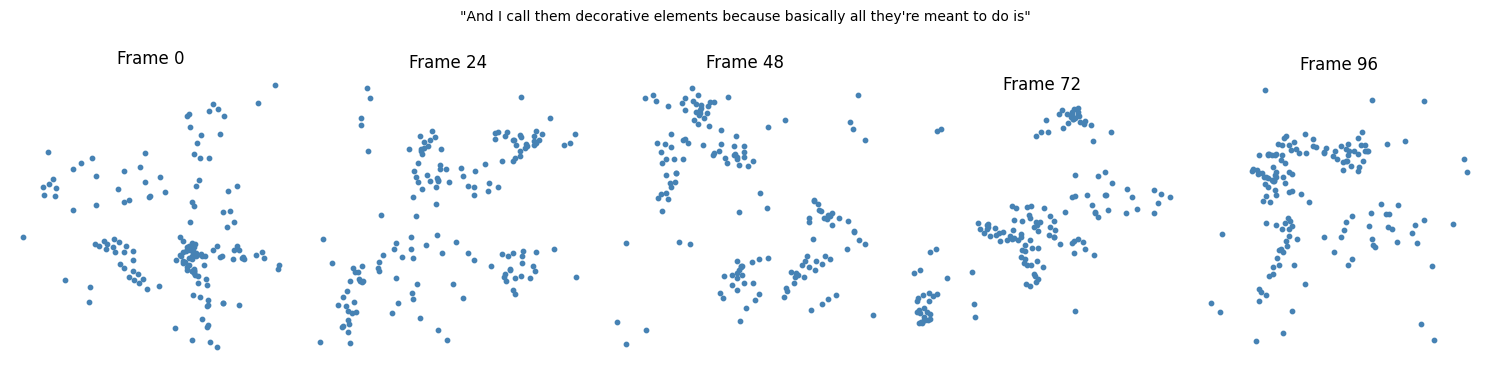

Séquence : 121 frames, 151 keypoints


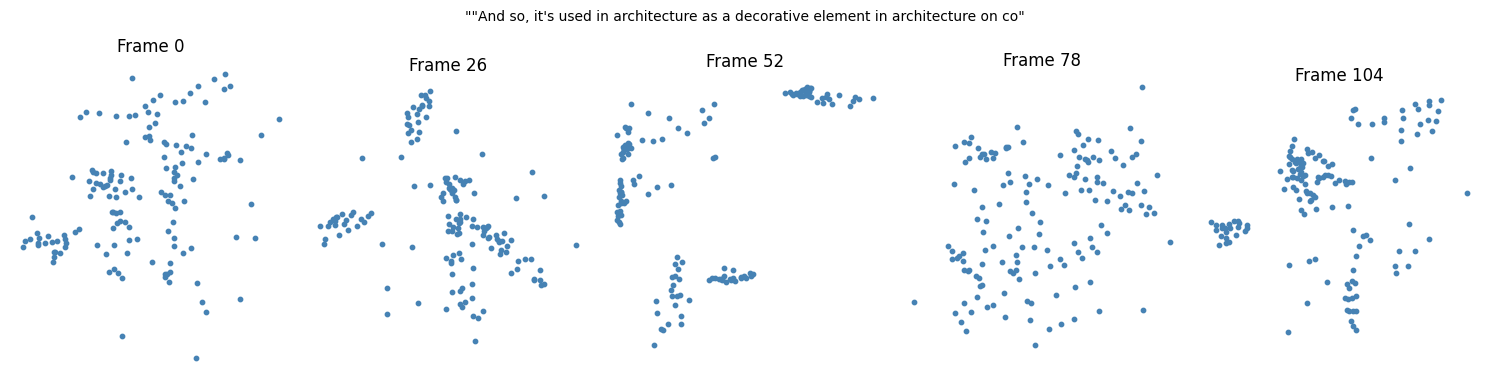

Séquence : 134 frames, 151 keypoints


In [42]:
def plot_skeleton_sample(dataset, idx=0):
    sample = dataset[idx]
    poses  = sample['poses'].numpy()   # (T, K, 3)
    text   = sample['text']

    # Afficher les 5 premiers frames
    fig, axes = plt.subplots(1, 5, figsize=(15, 4))
    for i, ax in enumerate(axes):
        frame_idx = i * (len(poses) // 5)
        frame     = poses[frame_idx]   # (K, 3)
        ax.scatter(frame[:, 0], -frame[:, 1], s=10, c='steelblue')
        ax.set_title(f'Frame {frame_idx}')
        ax.set_aspect('equal')
        ax.axis('off')

    fig.suptitle(f'"{text[:80]}"', fontsize=10)
    plt.tight_layout()
    plt.show()
    print(f"Séquence : {len(poses)} frames, {poses.shape[1]} keypoints")

train_ds = How2SignDataset('train', stats=stats, max_frames=500)
plot_skeleton_sample(train_ds, idx=0)
plot_skeleton_sample(train_ds, idx=5)